<a href="https://colab.research.google.com/github/matiasmorgan1/Master-s-by-Research/blob/main/Mankoff_et_al_(2020)_data_manipulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Mount Google Drive and import all libraries ---

from google.colab import drive
drive.mount('/content/drive')

# Core packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Spatial and geospatial analysis
!pip install geopandas shapely --quiet
import geopandas as gpd
from shapely.geometry import Point

# Optional: for statistical trend analysis
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



Mounted at /content/drive


In [ ]:
!pip install cmcrameri --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.4/277.4 kB 10.7 MB/s eta 0:00:00


# Regional Variability Mapping

In [ ]:
import requests

import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

In [ ]:
def get_discharge_links():
    url = 'https://dataverse.geus.dk/api/datasets/:persistentId/dirindex?persistentId=doi:10.22008/promice/data/ice_discharge/d/v02'
    html = requests.get(url).text
    soup = BeautifulSoup(html, 'html.parser')
    return {a.text.strip(): "https://dataverse.geus.dk" + a["href"] for a in soup.find_all("a")}

links = get_discharge_links()

In [ ]:
region_d_df = pd.read_csv(links['region_D.csv'], parse_dates=['Date'])
region_d_df

,Date,CE,CW,NE,NO,NW,SE,SW
0,1986-04-15,60.964342,68.136966,23.389923,21.571932,91.338628,143.411547,21.287977
1,1986-05-15,61.535856,76.570811,23.528506,20.851383,92.331071,144.236017,21.287977
2,1986-06-15,64.487583,76.072369,23.765864,24.261707,94.294983,142.216273,21.287977
3,1986-07-15,64.188037,75.592337,21.822940,25.388985,96.330931,142.776071,21.287977
4,1986-08-15,62.343568,73.505090,23.646478,24.177157,95.978622,144.408299,21.287977
...,...,...,...,...,...,...,...,...
2973,2026-04-29,74.167903,81.375979,31.293279,27.711506,116.178292,146.279954,20.307274
2974,2026-05-11,75.407519,81.421254,31.306380,27.578430,117.410460,144.753392,20.387847
2975,2026-05-23,74.361970,81.491525,31.362174,27.657518,114.438214,145.129413,20.513927
2976,2026-06-04,75.409077,82.873100,31.519202,27.579895,114.869876,145.635569,20.372610


In [ ]:
import pandas as pd

# Assuming you've already loaded the dataframe:
# region_d_df = pd.read_csv(links['region_D.csv'], parse_dates=['Date'])

# 1. Filter the dataframe for the years 1987 to 2025
mask = (region_d_df['Date'].dt.year >= 1986) & (region_d_df['Date'].dt.year <= 2025)
filtered_df = region_d_df.loc[mask]

# 2. Identify the columns representing the geographic regions
# This excludes 'Date' and any metadata/total columns like 'Total' or 'err' (error/uncertainty) if they exist
region_cols = [col for col in filtered_df.columns if col not in ['Date', 'Total', 'err', 'error']]

# 3. Compute total discharge vs. Southeast discharge
# Note: Because the values are rates (Gt/yr) sampled at daily intervals,
# summing them gives an amount proportional to the total mass lost over the period.
total_discharge_all_regions = filtered_df[region_cols].sum().sum()
total_discharge_se = filtered_df['SE'].sum()

# 4. Calculate the proportion
se_proportion = total_discharge_se / total_discharge_all_regions

# --- Print the Results ---
print(f"Regions included in calculation: {region_cols}")
print(f"Total summed discharge across all regions: {total_discharge_all_regions:,.2f} Gt")
print(f"Total summed discharge for Southeast (SE): {total_discharge_se:,.2f} Gt")
print(f"Southeast Proportion: {se_proportion:.4f} ({se_proportion * 100:.2f}%)")

Regions included in calculation: ['CE', 'CW', 'NE', 'NO', 'NW', 'SE', 'SW']
Total summed discharge across all regions: 1,448,028.36 Gt
Total summed discharge for Southeast (SE): 432,514.22 Gt
Southeast Proportion: 0.2987 (29.87%)


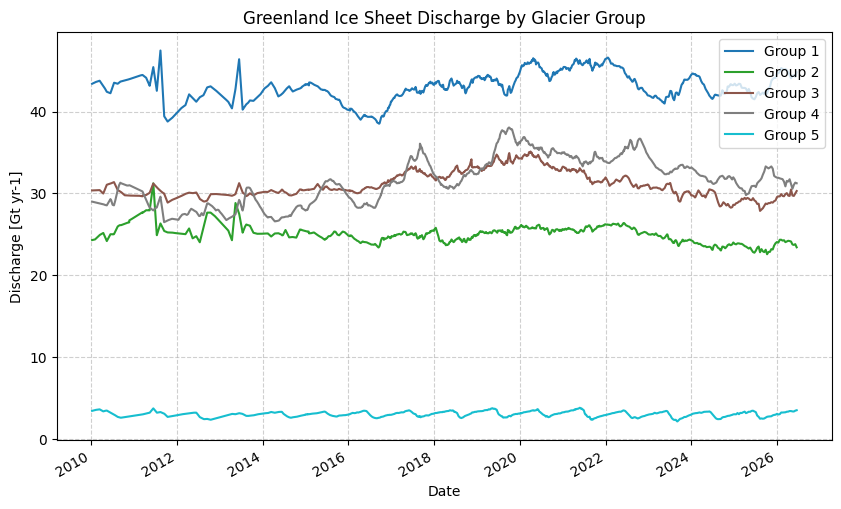

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the individual gate (glacier) data
# gate_D.csv contains the columns labeled with glacier IDs (239, 245, etc.)
gate_df = pd.read_csv(links['gate_D.csv'], parse_dates=['Date'])

# Your provided cluster dictionary
cluster_dict = {
    239:1, 245:1, 238:1, 286:1, 323:1, 320:1, 303:1, 300:1, 330:1,
    270:2, 258:2, 281:2, 233:2, 224:2,
    232:3, 266:3, 335:3, 310:3, 296:3, 293:3, 284:3, 302:3, 304:3,
    226:4, 227:4,
    297:5, 298:5
}

# 1. Ensure the Date column is in datetime format (if not already)
gate_df['Date'] = pd.to_datetime(gate_df['Date'])

# 2. Filter the DataFrame for dates from 2010 onwards
# This creates a new view of the data starting from January 1st, 2010
filtered_gate_df = gate_df[gate_df['Date'] >= '2010-01-01'].copy()

# 3. Create the grouped DataFrame using the filtered data
grouped_df = pd.DataFrame()
grouped_df['Date'] = filtered_gate_df['Date']

for group_num in sorted(set(cluster_dict.values())):
    # Match dictionary IDs to column headers
    ids_in_group = [str(k) for k, v in cluster_dict.items() if v == group_num and str(k) in filtered_gate_df.columns]

    if ids_in_group:
        # Sum the discharge for this group using the filtered data
        grouped_df[f'Group {group_num}'] = filtered_gate_df[ids_in_group].apply(pd.to_numeric, errors='coerce').sum(axis=1)

# 3. Plotting
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('tab10')

# Filter for the columns we actually created
group_cols = [c for c in grouped_df.columns if c.startswith('Group')]

if group_cols:
    grouped_df.plot(x='Date', y=group_cols, ax=ax, cmap=cmap)

    ax.set_ylabel('Discharge [Gt yr-1]')
    ax.set_title('Greenland Ice Sheet Discharge by Glacier Group')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.show()
else:
    print("No matching IDs found. Check if gate_df.columns contains the ID strings.")

Mounted at /content/drive


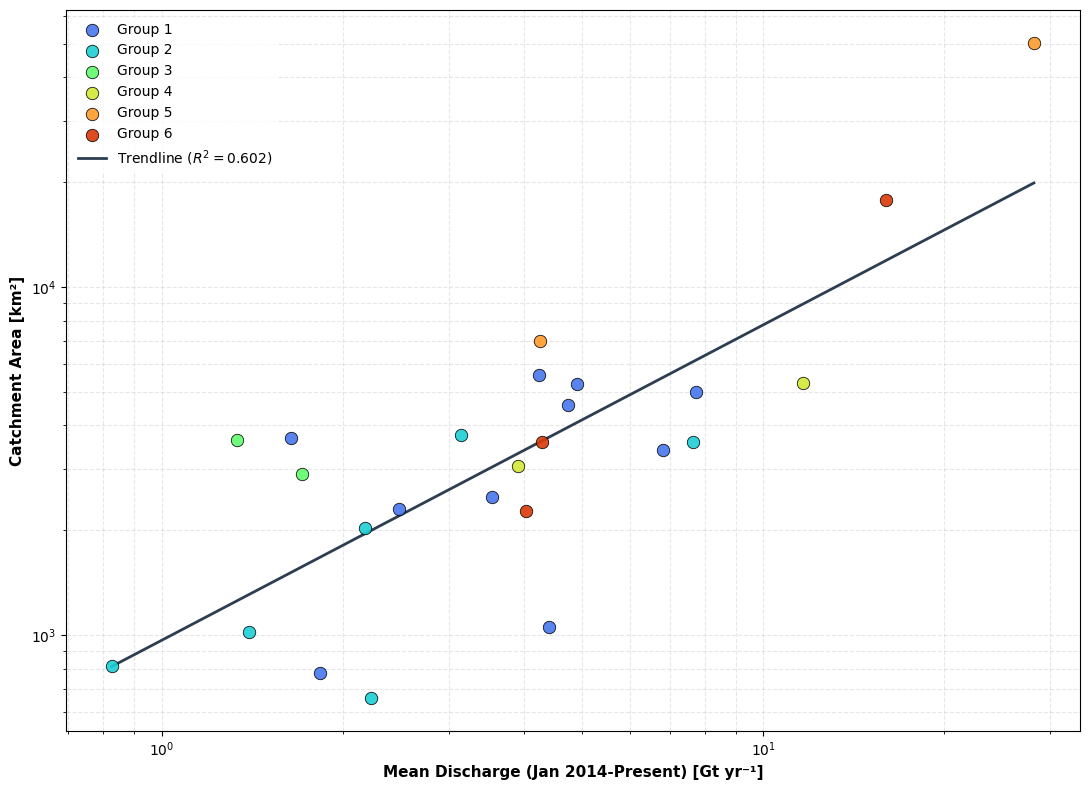

In [ ]:
import os
import re
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# ============================================================
# 1. MOUNT & DATA LOADING
# ============================================================
drive.mount("/content/drive", force_remount=True)

# File paths
catchment_file_path = "/content/drive/MyDrive/Spreadsheets/Catchments.xls"
gate_file_path = links["gate_D.csv"]

# Load both datasets
df_catchment = pd.read_excel(catchment_file_path)
gate_df = pd.read_csv(gate_file_path, parse_dates=["Date"])

# ============================================================
# 2. DATA PROCESSING & FILTERING (JAN 2014 - PRESENT)
# ============================================================
# Clean Catchment DataFrame
df_catchment.columns = df_catchment.columns.astype(str).str.strip()
id_col = "Glacier ID"
area_col = "Catchment Area (km2)"
df_catchment[id_col] = df_catchment[id_col].astype(str).str.strip()
df_catchment = df_catchment.set_index(id_col)

# Process Gate DataFrame for individual glacier mean discharge (2014 onwards)
gate_df["Date"] = pd.to_datetime(gate_df["Date"])
filtered_gate_df = gate_df[gate_df["Date"] >= "2014-01-01"].copy()

# Setup configurations (Updated Groups & Colors)
group_color_map = {
    1: "#4776EE",
    2: "#1BD0D5",
    3: "#61FC6C",
    4: "#D2E935",
    5: "#FE9B2D",
    6: "#DA3907",
}

cluster_dict = {
    # Cluster 1 (10 glaciers)
    232: 1,
    245: 1,
    296: 1,
    266: 1,
    284: 1,  # (286 omitted in favor of 284)
    293: 1,
    304: 1,
    300: 1,
    335: 1,
    310: 1,
    # Cluster 2 (6 glaciers)
    303: 2,
    320: 2,  # (323 omitted in favor of 320)
    302: 2,
    330: 2,
    281: 2,
    258: 2,
    # Cluster 3 (2 glaciers)
    298: 3,
    297: 3,
    # Cluster 4 (2 glaciers)
    233: 4,
    224: 4,
    # Cluster 5 (2 glaciers)
    227: 5,
    226: 5,
    # Cluster 6 (3 glaciers)
    238: 6,
    239: 6,
    270: 6,
}

# Define composite glacier pairs that need their discharges summed together
paired_targets = {
    320: {"label": "320/323", "pair_ids": [320, 323]},
    323: {"label": "320/323", "pair_ids": [320, 323]},
    284: {"label": "284/286", "pair_ids": [284, 286]},
    286: {"label": "284/286", "pair_ids": [284, 286]},
}

# Compile data points for valid glaciers
compiled_records = []
processed_glaciers = set()


# Helper function to match integer IDs against possible combined column names (e.g., "320/323")
def find_matching_key(target_id, keys_list):
  str_target = str(target_id)
  for key in keys_list:
    key_parts = re.findall(r"\d+", str(key))
    if str_target in key_parts:
      return key
  return None


for g_id, group_num in cluster_dict.items():
  # Check if glacier belongs to a composite sum pair
  if g_id in paired_targets:
    pair_info = paired_targets[g_id]
    label = pair_info["label"]
    record_id = f"{label}_{group_num}"

    if record_id in processed_glaciers:
      continue

    # Sum discharge across all sub-IDs forming the pair
    combined_discharge_series = None
    for sub_id in pair_info["pair_ids"]:
      match_col = find_matching_key(sub_id, filtered_gate_df.columns)
      if match_col:
        s = pd.to_numeric(filtered_gate_df[match_col], errors="coerce")
        if combined_discharge_series is None:
          combined_discharge_series = s.copy()
        else:
          combined_discharge_series = combined_discharge_series.add(
              s, fill_value=0
          )

    if combined_discharge_series is not None:
      mean_discharge = combined_discharge_series.mean()
    else:
      continue

    # Fetch shared Catchment Area
    catchment_key = find_matching_key(g_id, df_catchment.index)
    if not catchment_key:
      continue
    catchment_area = pd.to_numeric(
        df_catchment.loc[catchment_key, area_col], errors="coerce"
    )

    if mean_discharge > 0 and catchment_area > 0:
      compiled_records.append({
          "Glacier": label,
          "Discharge": mean_discharge,
          "Catchment_Area": catchment_area,
          "Group": group_num,
      })
      processed_glaciers.add(record_id)

  else:
    # Standard single glacier handling
    gate_key = find_matching_key(g_id, filtered_gate_df.columns)
    catchment_key = find_matching_key(g_id, df_catchment.index)

    if gate_key and catchment_key:
      record_id = f"{gate_key}_{group_num}"
      if record_id in processed_glaciers:
        continue

      mean_discharge = pd.to_numeric(
          filtered_gate_df[gate_key], errors="coerce"
      ).mean()
      catchment_area = pd.to_numeric(
          df_catchment.loc[catchment_key, area_col], errors="coerce"
      )

      if mean_discharge > 0 and catchment_area > 0:
        compiled_records.append({
            "Glacier": str(gate_key),
            "Discharge": mean_discharge,
            "Catchment_Area": catchment_area,
            "Group": group_num,
        })
        processed_glaciers.add(record_id)

plot_df = pd.DataFrame(compiled_records)

# ============================================================
# 3. LOG-LOG LINE OF BEST FIT CALCULATION (Power Law)
# ============================================================
x_data = plot_df["Discharge"].values
y_data = plot_df["Catchment_Area"].values

# Fit a linear line to log-transformed variables
log_x = np.log10(x_data)
log_y = np.log10(y_data)
slope, intercept = np.polyfit(log_x, log_y, 1)

# Generate predictions in log space to calculate true R2 score
log_y_pred = slope * log_x + intercept
r2_val = r2_score(log_y, log_y_pred)

# Create smooth evaluation points for plotting trendline
x_line = np.linspace(x_data.min(), x_data.max(), 100)
y_line = 10**intercept * (x_line**slope)

# ============================================================
# 4. PLOTTING DISCHARGE (X) VS CATCHMENT AREA (Y) - LOG SCALES
# ============================================================
fig, ax = plt.subplots(figsize=(11, 8))

# Plot the individual groups
clusters = sorted(plot_df["Group"].unique())
for group in clusters:
  group_data = plot_df[plot_df["Group"] == group]
  color = group_color_map.get(group, "#000000")

  ax.scatter(
      group_data["Discharge"],
      group_data["Catchment_Area"],
      color=color,
      s=80,
      label=f"Group {int(group)}",
      edgecolors="black",
      linewidths=0.6,
      alpha=0.9,
      zorder=3,
  )

# Plot Trendline on log-log space
ax.plot(
    x_line,
    y_line,
    color="#2c3e50",
    linestyle="-",
    linewidth=2,
    label=f"Trendline ($R^2 = {r2_val:.3f}$)",
    zorder=2,
)

# Apply Logarithmic transformations
ax.set_xscale("log")
ax.set_yscale("log")

# Grid and Label Styling
ax.set_xlabel(
    "Mean Discharge (Jan 2014-Present) [Gt yr⁻¹]",
    fontweight="bold",
    fontsize=11,
)
ax.set_ylabel("Catchment Area [km²]", fontweight="bold", fontsize=11)
ax.set_title("", fontweight="bold", fontsize=14, pad=15)
ax.grid(True, which="both", linestyle="--", alpha=0.3, zorder=1)

# Add Legend
ax.legend(
    frameon=True, facecolor="white", edgecolor="none", fontsize=10, loc="best"
)

plt.tight_layout()
plt.show()

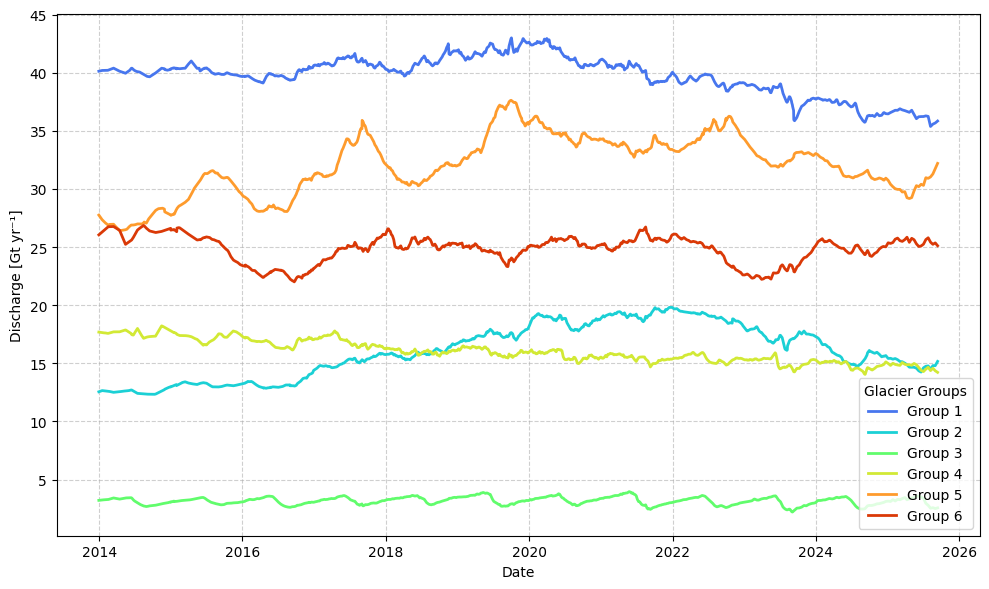

In [ ]:
"""COLOURBLIND FRIENDLY"""

import re
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the individual gate (glacier) data from Google Drive
file_path = (
    "/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge/gate_D.csv"
)
gate_df = pd.read_csv(file_path, parse_dates=["Date"])

# Updated cluster dictionary (6 clusters)
cluster_dict = {
    # Cluster 1 (10 glaciers)
    232: 1,
    245: 1,
    296: 1,
    266: 1,
    284: 1,  # (286 omitted in favor of 284)
    293: 1,
    304: 1,
    300: 1,
    335: 1,
    310: 1,
    # Cluster 2 (6 glaciers)
    303: 2,
    320: 2,  # (323 omitted in favor of 320)
    302: 2,
    330: 2,
    281: 2,
    258: 2,
    # Cluster 3 (2 glaciers)
    298: 3,
    297: 3,
    # Cluster 4 (2 glaciers)
    233: 4,
    224: 4,
    # Cluster 5 (2 glaciers)
    227: 5,
    226: 5,
    # Cluster 6 (3 glaciers)
    238: 6,
    239: 6,
    270: 6,
}

# Updated explicit color palette per group
group_colors = {
    1: "#4776EE",
    2: "#1BD0D5",
    3: "#61FC6C",
    4: "#D2E935",
    5: "#FE9B2D",
    6: "#DA3907",
}

# 1. Ensure the Date column is in datetime format
gate_df["Date"] = pd.to_datetime(gate_df["Date"])

# 2. Filter for dates from 2013-12-30 onwards
filtered_gate_df = gate_df[gate_df["Date"] >= "2013-12-30"].copy()

# 3. Create the grouped DataFrame
grouped_df = pd.DataFrame()
grouped_df["Date"] = filtered_gate_df["Date"]

groups = sorted(set(cluster_dict.values()))

for group_num in groups:
  # Target IDs belonging to this cluster group
  target_ids = [k for k, v in cluster_dict.items() if v == group_num]

  # Dynamically match column names (handles single IDs like '302' or combined headers like '320/323')
  matching_cols = []
  for col in filtered_gate_df.columns:
    if col == "Date":
      continue
    # Extract digits from column header
    col_digits = [int(d) for d in re.findall(r"\d+", str(col))]
    if any(g_id in target_ids for g_id in col_digits):
      if col not in matching_cols:
        matching_cols.append(col)

  if matching_cols:
    grouped_df[f"Group {group_num}"] = (
        filtered_gate_df[matching_cols]
        .apply(pd.to_numeric, errors="coerce")
        .sum(axis=1)
    )

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

group_cols = [c for c in grouped_df.columns if c.startswith("Group")]

if group_cols:
  # Loop through columns and extract group number to map exact color
  for col in group_cols:
    group_num = int(col.split()[-1])
    color = group_colors.get(group_num, "#000000")  # Fallback to black

    ax.plot(
        grouped_df["Date"], grouped_df[col], label=col, color=color, lw=2
    )

  ax.set_ylabel("Discharge [Gt yr⁻¹]")
  ax.set_xlabel("Date")
  ax.set_title("")
  ax.grid(True, linestyle="--", alpha=0.6)
  ax.legend(title="Glacier Groups", frameon=True)

  plt.tight_layout()
  plt.show()
else:
  print("No matching IDs found.")

<>:167: SyntaxWarning: invalid escape sequence '\m'
<>:167: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2927/1282428015.py:167: SyntaxWarning: invalid escape sequence '\m'
  "Discharge\n[$\mathrm{Gt\ yr^{-1}}$]", fontsize=12, fontweight="bold"


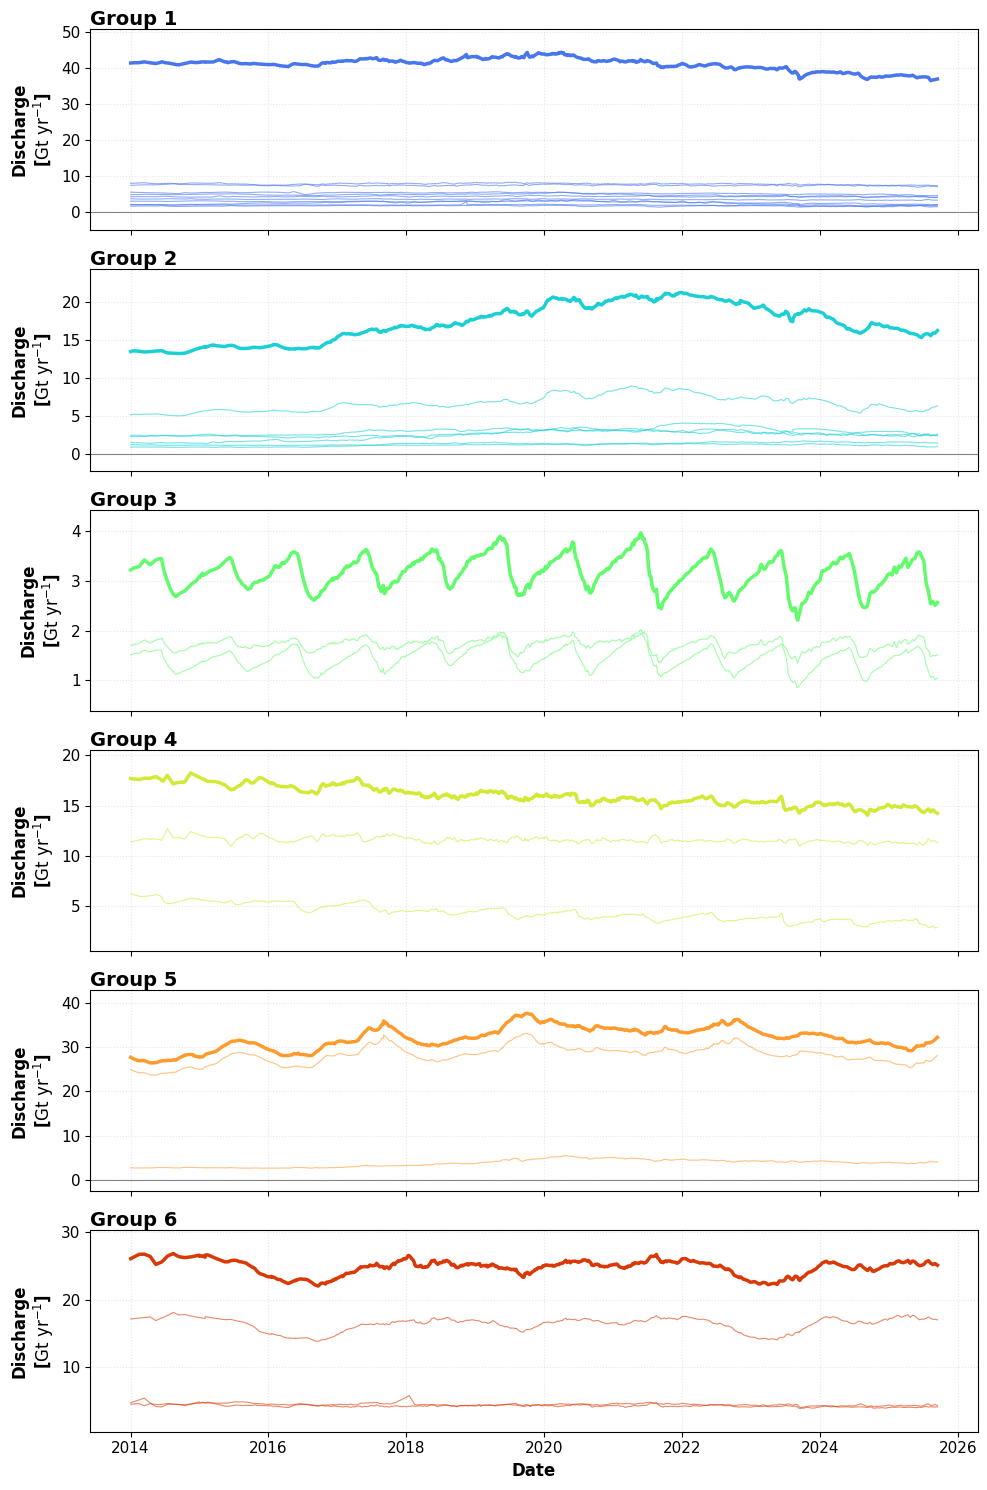

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. LOAD AND FILTER DATA FROM MOUNTED DRIVE
file_path = (
    "/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge/gate_D.csv"
)
gate_df = pd.read_csv(file_path, parse_dates=["Date"])
gate_df["Date"] = pd.to_datetime(gate_df["Date"])

# Filter for data from 2014 onwards
filtered_gate_df = gate_df[gate_df["Date"] >= "2014-01-01"].copy()

# ============================================================
# COMBINE SPECIFIC GLACIER PAIRS (320+323 AND 284+286)
# ============================================================
paired_definitions = {
    "320/323": [320, 323],
    "284/286": [284, 286],
}


def find_matching_cols(target_ids, df_columns):
  matched = []
  for col in df_columns:
    if col == "Date":
      continue
    digits = [int(d) for d in re.findall(r"\d+", str(col))]
    if any(tid in digits for tid in target_ids):
      matched.append(col)
  return matched


for pair_label, sub_ids in paired_definitions.items():
  matching_cols = find_matching_cols(sub_ids, filtered_gate_df.columns)
  if matching_cols:
    # Convert matching columns to numeric and sum row-wise across dates
    summed_series = (
        filtered_gate_df[matching_cols]
        .apply(pd.to_numeric, errors="coerce")
        .sum(axis=1)
    )

    # Drop original columns and assign the new combined pair column
    filtered_gate_df = filtered_gate_df.drop(columns=matching_cols)
    filtered_gate_df[pair_label] = summed_series

# 2. CONFIGURATION & EXACT HEX COLOR SELECTION (6 CLUSTERS)
cluster_dict = {
    # Cluster 1 (10 glaciers)
    232: 1,
    245: 1,
    296: 1,
    266: 1,
    284: 1,  # (286 omitted in favor of 284)
    293: 1,
    304: 1,
    300: 1,
    335: 1,
    310: 1,
    # Cluster 2 (6 glaciers)
    303: 2,
    320: 2,  # (323 omitted in favor of 320)
    302: 2,
    330: 2,
    281: 2,
    258: 2,
    # Cluster 3 (2 glaciers)
    298: 3,
    297: 3,
    # Cluster 4 (2 glaciers)
    233: 4,
    224: 4,
    # Cluster 5 (2 glaciers)
    227: 5,
    226: 5,
    # Cluster 6 (3 glaciers)
    238: 6,
    239: 6,
    270: 6,
}


unique_groups = sorted(set(cluster_dict.values()))

# Directly map your exact color specifications per group
group_colors = {
    1: "#4776EE",
    2: "#1BD0D5",
    3: "#61FC6C",
    4: "#D2E935",
    5: "#FE9B2D",
    6: "#DA3907",
}

# 3. PLOTTING STACKED SUBPLOTS
n_clusters = len(unique_groups)
fig, axes = plt.subplots(
    n_clusters, 1, figsize=(10, 2.5 * n_clusters), sharex=True
)

if n_clusters == 1:
  axes = [axes]

for i, group_num in enumerate(unique_groups):
  ax = axes[i]
  base_color = group_colors[group_num]

  # Target IDs belonging to this cluster group
  target_ids = [k for k, v in cluster_dict.items() if v == group_num]

  # Identify valid columns in updated dataframe (including new "320/323" and "284/286" columns)
  matching_cols = []
  for col in filtered_gate_df.columns:
    if col == "Date":
      continue
    col_digits = [int(d) for d in re.findall(r"\d+", str(col))]
    if any(g_id in target_ids for g_id in col_digits):
      if col not in matching_cols:
        matching_cols.append(col)

  if not matching_cols:
    ax.text(
        0.5, 0.5, f"No data for Group {group_num}", ha="center", va="center"
    )
    continue

  group_data = filtered_gate_df[matching_cols].apply(
      pd.to_numeric, errors="coerce"
  )

  # Calculate Total Discharge for the group
  group_total = group_data.sum(axis=1)

  # Dynamic Y-limits
  g_min = group_data.min().min()
  g_max = group_total.max()
  y_buffer = (g_max - g_min) * 0.15 if g_max != g_min else 0.5

  # A. PLOT INDIVIDUAL GLACIERS / COMBINED PAIRS (Raw Data)
  for col in matching_cols:
    ax.plot(
        filtered_gate_df["Date"],
        group_data[col],
        color=base_color,
        alpha=0.6,
        linewidth=0.8,
        zorder=2,
    )

  # B. PLOT GROUP TOTAL MONTHLY DISCHARGE
  ax.plot(
      filtered_gate_df["Date"],
      group_total,
      color=base_color,
      alpha=1.0,
      linewidth=2.5,
      linestyle="-",
      zorder=4,
  )

  # SUBPLOT FORMATTING
  ax.set_ylim(g_min - y_buffer, g_max + y_buffer)
  ax.set_ylabel(
      "Discharge\n[$\mathrm{Gt\ yr^{-1}}$]", fontsize=12, fontweight="bold"
  )
  ax.set_title(
      f"Group {group_num}",
      loc="left",
      fontsize=14,
      fontweight="bold",
      color="black",
      pad=-15,
  )

  ax.grid(True, linestyle=":", alpha=0.3)
  ax.tick_params(axis="both", labelsize=11)
  ax.axhline(0, color="black", linewidth=0.8, alpha=0.5, zorder=1)

# 4. FINAL FIGURE FORMATTING
axes[-1].set_xlabel("Date", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# 1. CLEAN UP THE DATAFRAME
# Dropping the temporary column used for sorting to keep the shapefile tidy
export_points = points.drop(columns=['y_coord'])

# 2. DEFINE OUTPUT FILENAME
# This will save it in the same 'Discharge_Map' folder on your Drive
output_filename = "Glacier_Points_with_Groups.shp"
output_path = path + output_filename

# 3. EXPORT TO GOOGLE DRIVE
try:
    export_points.to_file(output_path, driver='ESRI Shapefile')
    print(f"Successfully exported shapefile to: {output_path}")
except Exception as e:
    print(f"An error occurred during export: {e}")

Successfully exported shapefile to: /content/drive/MyDrive/Discharge_Map/Glacier_Points_with_Groups.shp


# Load Data and Mapping

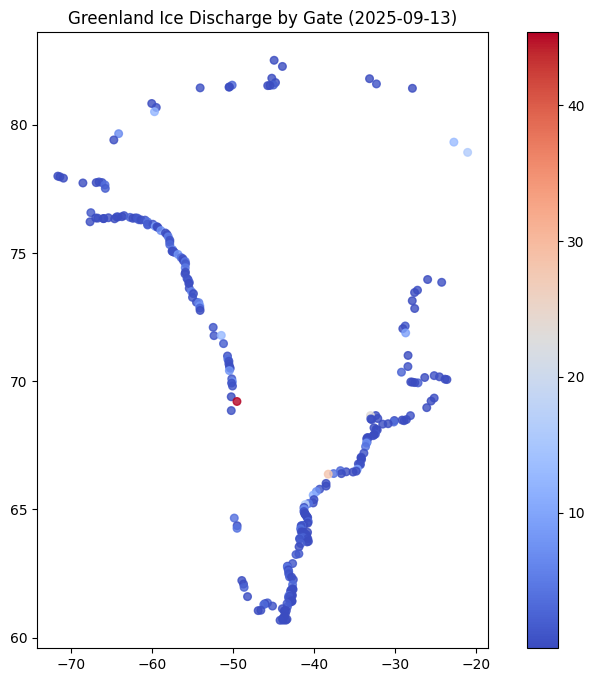

In [ ]:
# --- Load the data ---
gate_d_path = '/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge/gate_D.csv'
meta_path = '/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge/gate_meta.csv'

df = pd.read_csv(gate_d_path)
meta = pd.read_csv(meta_path)

# --- Ensure the first column is named "Date" ---
df.rename(columns={df.columns[0]: "Date"}, inplace=True)

# --- Convert to datetime (handles year or date formats) ---
if np.issubdtype(df["Date"].dtype, np.number):
    # Convert numeric years to datetime
    df["Date"] = pd.to_datetime(df["Date"].astype(int), format='%Y')
else:
    # Try parsing regular date strings
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# --- Reshape discharge data from wide to long format ---
df_long = df.melt(id_vars=["Date"], var_name="gate", value_name="discharge")

# Convert gate IDs to string to match metadata
df_long["gate"] = df_long["gate"].astype(str)
meta["gate"] = meta["gate"].astype(str)

# --- Merge discharge data with gate metadata ---
df_merged = df_long.merge(meta, on="gate", how="left")

# --- Create GeoDataFrame ---
gdf = gpd.GeoDataFrame(
    df_merged,
    geometry=gpd.points_from_xy(df_merged["lon"], df_merged["lat"]),
    crs="EPSG:4326"
)

# --- Filter for most recent date ---
latest_date = gdf["Date"].max()
gdf_latest = gdf[gdf["Date"] == latest_date]

# --- Plot latest discharge snapshot ---
fig, ax = plt.subplots(figsize=(10, 8))
gdf_latest.plot(
    ax=ax,
    column="discharge",
    cmap="coolwarm",
    legend=True,
    markersize=30,
    alpha=0.8
)
ax.set_title(f"Greenland Ice Discharge by Gate ({latest_date.date()})")
plt.show()


In [ ]:
# @title
'''SAVE ALL VECTOR POINTS'''

# --- Load data ---
df = pd.read_csv(gate_d_path)
meta = pd.read_csv(meta_path)

# --- Reshape discharge data ---
df_long = df.melt(id_vars=["Date"], var_name="gate", value_name="discharge")
df_long["Date"] = pd.to_datetime(df_long["Date"], errors="coerce")

# --- Convert gate IDs to strings ---
df_long["gate"] = df_long["gate"].astype(str)
meta["gate"] = meta["gate"].astype(str)

# --- Merge discharge data with metadata ---
df_merged = df_long.merge(meta, on="gate", how="left")

# --- Compute mean (or sum) discharge per gate ---
agg = (
    df_merged.groupby(["gate", "lon", "lat"], as_index=False)
    .agg(mean_discharge=("discharge", "mean"))
)

# --- Ensure coordinates are numeric ---
agg["lon"] = pd.to_numeric(agg["lon"], errors="coerce")
agg["lat"] = pd.to_numeric(agg["lat"], errors="coerce")
agg = agg.dropna(subset=["lon", "lat"])

# --- Create GeoDataFrame in WGS84 ---
gdf = gpd.GeoDataFrame(
    agg,
    geometry=gpd.points_from_xy(agg["lon"], agg["lat"]),
    crs="EPSG:4326"
)

# --- Reproject to Polar Stereographic North (EPSG:3413) ---
gdf_polar = gdf.to_crs("EPSG:3413")

# --- Save shapefile ---
output_path = "/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge_Gates_Aggregated_PSN.shp"
gdf_polar.to_file(output_path)

print(f"✅ Aggregated shapefile saved to:\n{output_path}")
print(f"🧭 CRS: {gdf_polar.crs}")
print(f"📍 Number of gates: {len(gdf_polar)}")



/tmp/ipython-input-1331041733.py:42: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_polar.to_file(output_path)


✅ Aggregated shapefile saved to:
/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge_Gates_Aggregated_PSN.shp
🧭 CRS: EPSG:3413
📍 Number of gates: 266


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'mean_discharge' to 'mean_disch'
  ogr_write(


In [ ]:
# List of glaciers in the study.

seg_gate_list = [
    '224','225','226','227','229','230','231','232','233','234','237','238','239','240',
    '245','246','248','251','252','253','254','257','258','260','265','266',
    '268','270','271','272','274','275','276','277','278','279','280','281',
    '283','284','286','289','290','293','294','296','297','298','299','300',
    '301','302','303','304','305','308','310','312','313','314','316','317',
    '318','319','320','322','323','325','326','327','328','330','335','336',
    '339','340','341','343','344','346','347','348','349','350','351'
]

In [ ]:
'''SAVE TO SHAPEFILE - SE GREENLAND ONLY'''

# --- Use df_merged (time series data) instead of aggregated gdf ---
gdf_se_all = df_merged[df_merged['gate'].isin(seg_gate_list)].copy()

print(f"✅ Gates in study region: {len(seg_gate_list)}")
print(f"📊 Gates found in dataset: {gdf_se_all['gate'].nunique()}")

missing_gates = set(seg_gate_list) - set(gdf_se_all['gate'].unique())
if missing_gates:
    print('⚠️ Missing gates:', missing_gates)
else:
    print('All study-region gates successfully included!')

# --- Convert to GeoDataFrame ---
gdf_se_all = gpd.GeoDataFrame(
    gdf_se_all,
    geometry=gpd.points_from_xy(gdf_se_all['lon'], gdf_se_all['lat']),
    crs="EPSG:4326"
)

# --- Reproject to Polar Stereographic North (EPSG:3413) ---
gdf_se_all_polar = gdf_se_all.to_crs("EPSG:3413")

# --- Save shapefile ---
output_path = "/content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge/SE_Greenland_Gates_FullTimeSeries_PSN.shp"
gdf_se_all_polar.to_file(output_path)

print(f"✅ Vector layer saved to {output_path}")
print(f"🧭 CRS: {gdf_se_all_polar.crs}")
print(f"📍 Number of records exported: {len(gdf_se_all_polar)}")


✅ Gates in study region: 85
📊 Gates found in dataset: 85
All study-region gates successfully included!


/tmp/ipython-input-665232388.py:27: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_se_all_polar.to_file(output_path)


✅ Vector layer saved to /content/drive/MyDrive/MRes_Discharge/Mankoff_Discharge/SE_Greenland_Gates_FullTimeSeries_PSN.shp
🧭 CRS: EPSG:3413
📍 Number of records exported: 248795


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Field Date created as String field, though DateTime requested.
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Mouginot_2019' to 'Mouginot_2'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Zwally_2012' to 'Zwally_201'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Moon_2008_dist' to 'Moon_2008_'
  ogr_write(


In [ ]:
# ============================================================
# EXPORT FIGURE DATA TO EXCEL
#   1) Anomaly (Gt/yr)
#   2) Normalised anomaly (z-score)
# ============================================================

out_dir = "/content/drive/MyDrive/MRes_Discharge/Discharge_Excel"
os.makedirs(out_dir, exist_ok=True)

# ------------------------
# 1. ANOMALY DATA
# ------------------------
anom_excel = os.path.join(
    out_dir,
    "Monthly_Discharge_Anomaly_2014_2025_Baseline1991_2011.xlsx"
)

export_anom = pivot_anom.copy()
export_anom.insert(0, "gate", export_anom.index)

export_anom.to_excel(
    anom_excel,
    index=False
)

print(f"Saved anomaly data -> {anom_excel}")

# ------------------------
# 2. NORMALISED (Z-SCORE) DATA
# ------------------------
norm_excel = os.path.join(
    out_dir,
    "Monthly_Discharge_Normalised_Zscore_2014_2025.xlsx"
)

export_norm = pivot_norm.copy()
export_norm.insert(0, "gate", export_norm.index)

export_norm.to_excel(
    norm_excel,
    index=False
)

print(f"Saved normalised data -> {norm_excel}")


Saved anomaly data -> /content/drive/MyDrive/MRes_Discharge/Discharge_Excel/Monthly_Discharge_Anomaly_2014_2025_Baseline1991_2011.xlsx
Saved normalised data -> /content/drive/MyDrive/MRes_Discharge/Discharge_Excel/Monthly_Discharge_Normalised_Zscore_2014_2025.xlsx
